In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import xgboost as xgb
from math import ceil
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, AdaBoostClassifier, AdaBoostRegressor, GradientBoostingClassifier, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score

def draw_normal_dist(data) :
    x = np.linspace(data.min(), data.max(), 100)
    p = stats.norm.pdf(x, data.mean(), data.std())
    plt.plot(x, p, 'k', linewidth=2)
    
    plt.title('Distribution avec courbe de la loi normale')
    plt.xlabel('Valeurs')
    plt.ylabel('Densité')


In [121]:
# Class DataAnalysis

class DataAnalysis:
   def __init__(self, df) -> None:
      self.df = df.copy()
      self.categorical_data = df.select_dtypes(include='object')
      self.numeric_data = df.select_dtypes("number")
   
   # Numeric variable analysis
   def check_null(self) -> None:
      print(f'Nbre de valeur manquante dans la dataframe :\n {self.df.isnull().sum().sum()}')
      if (self.df.isnull().sum().sum()>1):
         print(f"Nbre de valeur manquante par colonne de la dataframe :\n {self.df.isnull().sum()} ")
   def num_boxplot(self) -> None:
      NumericAnalysis(self.numeric_data).boxplot()

   def corr_heatmap(self) -> None :
      NumericAnalysis(self.numeric_data).corr_matrix()

   # Categorical variable analysis
   def cat_summary(self) -> None :
      CategoricalAnalysis(self.categorical_data).summary()
   def cat_encode(self) :
      CategoricalAnalysis(self.categorical_data).encode(self.categorical_data)
      
# Class Categorical Analysis

class CategoricalAnalysis:
   def __init__(self, df) -> None:
      self.df = df.copy()
   def summary(self) -> None:
      # Comptage valeur unique et description des varaibles qualitatives
      print(self.df.describe(include='object'))

      # Comptage des modalités par variables qualitatives
      for cat in self.df :
         print(self.df[cat].value_counts())
   def encode(self, p=0.05) -> pd.DataFrame :
      data_encoded = self.df.copy()
      categorical_data = self.df.select_dtypes(include='object')
      for cat in categorical_data :
         
         columns_array = data_encoded[cat].to_numpy().reshape(-1,1)
         one_hot_encoder = OneHotEncoder(sparse_output=False).fit(columns_array)
         data_enc = one_hot_encoder.transform(columns_array)
         df_enc = pd.DataFrame(data_enc, columns = one_hot_encoder.get_feature_names_out([cat]))
         data_encoded = pd.concat([data_encoded,df_enc],axis=1)
         data_encoded = data_encoded.drop(columns=cat)

      return data_encoded
      
# Class Numerical Analysis

class NumericAnalysis:

   def __init__(self, numeric_data) -> None:
      self.numeric_data = numeric_data.copy()
   def boxplot(self) -> None:
      n_cols = len(self.numeric_data.columns)
      n_rows = ceil(n_cols / 3)
      
      fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows)) 
      axes = axes.flatten()  # Aplatir les axes pour itérer facilement
      
      for i, col in enumerate(self.numeric_data.columns):
         sns.boxplot(y=self.numeric_data[col], ax=axes[i])
         axes[i].set_title(f"{col}")
         axes[i].set_ylabel("Valeurs")
         axes[i].set_xlabel("")  # Pas d'étiquette pour l'axe X
      
      # Supprimer les axes inutilisés si le nombre de colonnes est inférieur à la grille
      for j in range(i + 1, len(axes)):
         fig.delaxes(axes[j])
      
      plt.tight_layout()
      plt.show()

   def corr_matrix(self) -> None:
      sns.heatmap(data=self.numeric_data.corr())

In [122]:
# 1. Importation des données

data = pd.read_csv("database/insurance_claims_small.csv")
sns.set_style('whitegrid')

data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [123]:
# 2. Feature engineering

In [124]:
# Suppression des variables inutiles

data = data[["age", "policy_state", "insured_zip", "insured_sex", "auto_make", "auto_model", "auto_year", "total_claim_amount"]]
data_analysis = DataAnalysis(data)
numeric_data = data_analysis.numeric_data
categorical_data = data_analysis.categorical_data


data.head()

,age,policy_state,insured_zip,insured_sex,auto_make,auto_model,auto_year,total_claim_amount
0,48,OH,466132,MALE,Saab,92x,2004,71610
1,42,IN,468176,MALE,Mercedes,E400,2007,5070
2,29,OH,430632,FEMALE,Dodge,RAM,2007,34650
3,41,IL,608117,FEMALE,Chevrolet,Tahoe,2014,63400
4,44,IL,610706,MALE,Accura,RSX,2009,6500


In [125]:
# Vérification de valeur manquante

data_analysis.cat_summary()

       policy_state insured_sex auto_make auto_model
count          1000        1000      1000       1000
unique            3           2        14         39
top              OH      FEMALE      Saab        RAM
freq            352         537        80         43
policy_state
OH    352
IL    338
IN    310
Name: count, dtype: int64
insured_sex
FEMALE    537
MALE      463
Name: count, dtype: int64
auto_make
Saab          80
Dodge         80
Suburu        80
Nissan        78
Chevrolet     76
Ford          72
BMW           72
Toyota        70
Audi          69
Accura        68
Volkswagen    68
Jeep          67
Mercedes      65
Honda         55
Name: count, dtype: int64
auto_model
RAM               43
Wrangler          42
A3                37
Neon              37
MDX               36
Jetta             35
Passat            33
A5                32
Legacy            32
Pathfinder        31
Malibu            30
92x               28
Camry             28
Forrestor         28
F150              27


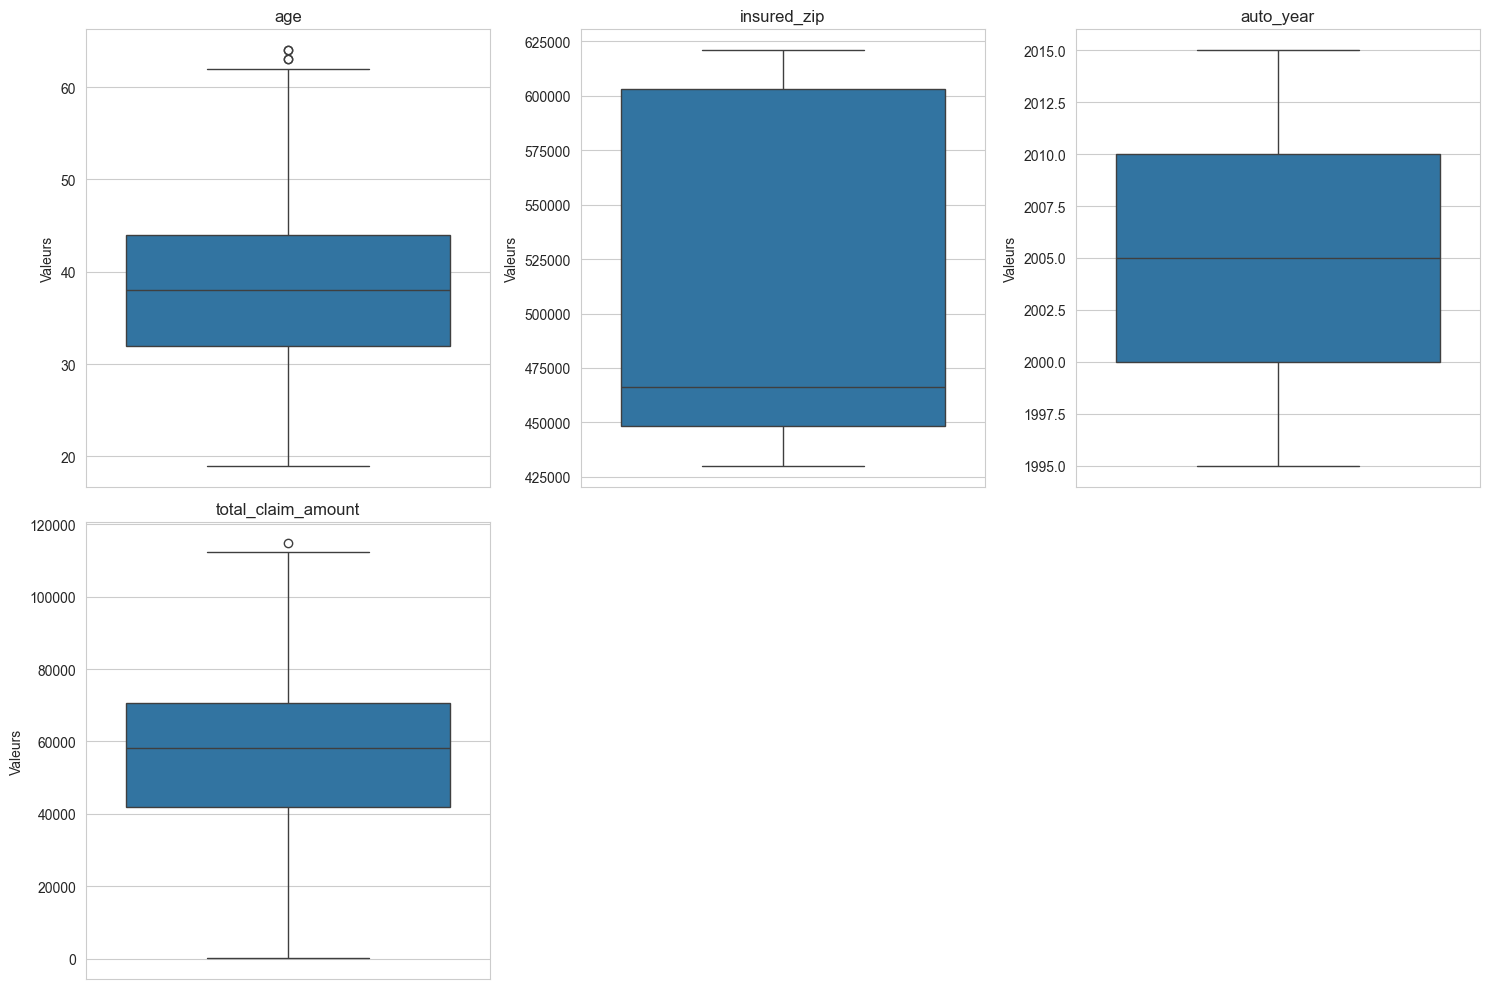

In [126]:
# Visualisation et vérification des valeurs extremes

data_analysis.num_boxplot()

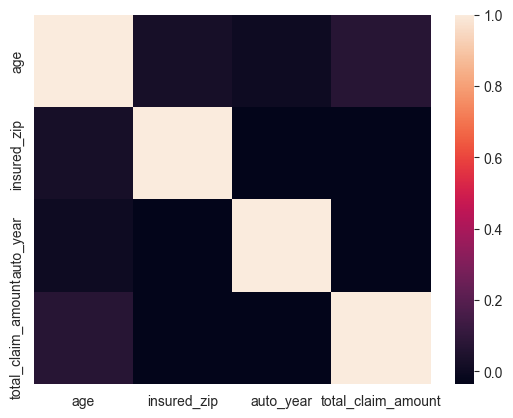

In [127]:
# Correlation HeatMap

data_analysis.corr_heatmap()

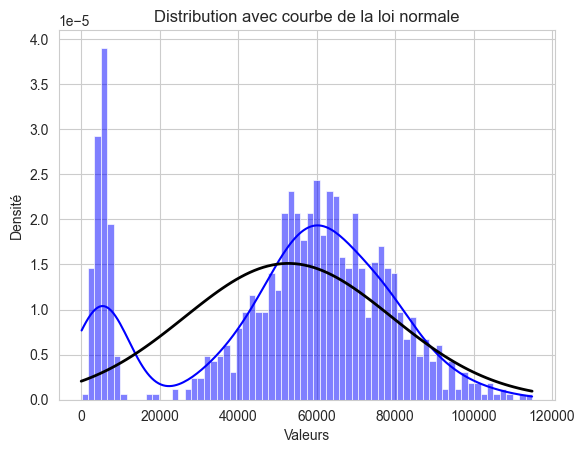

In [8]:
# 3. Conception d'une baseline (GLM)

# Distribution des couts de sinistres

mnt_sinistres = data['total_claim_amount']

# Visualisation

sns.histplot(data=mnt_sinistres, kde=True, color='blue', bins=70, stat="density")

# Ajout de la courbe de la loi normale

x = np.linspace(0, 114920, 100)
p = stats.norm.pdf(x, mnt_sinistres.mean(), mnt_sinistres.std())
plt.plot(x, p, 'k', linewidth=2)

plt.title('Distribution avec courbe de la loi normale')
plt.xlabel('Valeurs')
plt.ylabel('Densité')
plt.show()

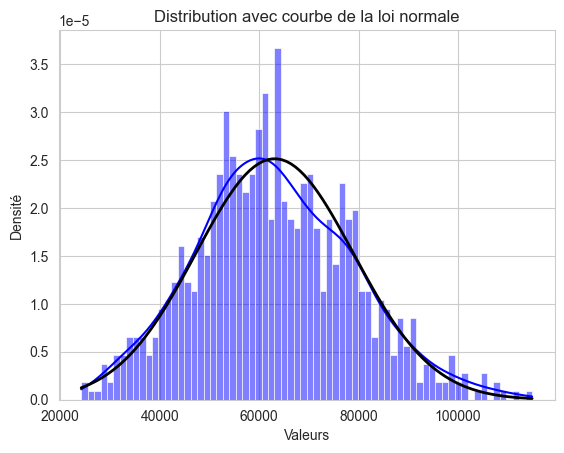

In [9]:
# 3.1 Séparation des données et approximation

# Bornes supérieures (montant de sinistres sup à 20 000)

mnt_sup = mnt_sinistres[mnt_sinistres > 20000]


# Visualisation

sns.histplot(data=mnt_sup, kde=True, color='blue', bins=70, stat="density")

# Ajout de la courbe de la loi normale

draw_normal_dist(mnt_sup)
plt.show()

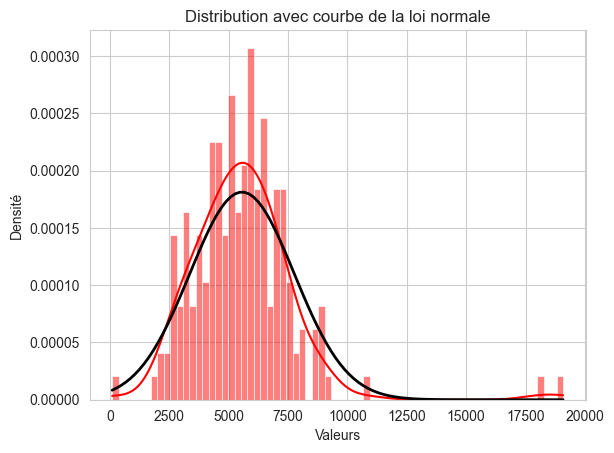

In [10]:
# Bornes inférieures (montant de sinistres sup à 20 000)

mnt_inf = mnt_sinistres[mnt_sinistres <= 20000]

# Visualisation

sns.histplot(x=mnt_inf, kde=True, color='red', bins=70, stat='density')
draw_normal_dist(mnt_inf)
plt.show()

In [11]:
# 3.2 Régression linéaire

data_clean = data.drop(columns=['total_claim_amount'])
data_clean.head()

,age,policy_state,insured_zip,insured_sex,auto_make,auto_model,auto_year
0,48,OH,466132,MALE,Saab,92x,2004
1,42,IN,468176,MALE,Mercedes,E400,2007
2,29,OH,430632,FEMALE,Dodge,RAM,2007
3,41,IL,608117,FEMALE,Chevrolet,Tahoe,2014
4,44,IL,610706,MALE,Accura,RSX,2009


In [114]:
# Encodage des variables catégorielles

### !!! A éviter !!!!
## label_encoder = LabelEncoder()
## Nos variables catégorielles ici n'ont pas d'ordre spécifique ainsi le label encoding ne sera pas approprié

# L'on pourrait aussi utiliser get_dummies de Pandas mais il est préferrable d'utiliser OneHotEncoder qui reapplique la meme structure d'encodage
# https://contactsunny.medium.com/label-encoder-vs-one-hot-encoder-in-machine-learning-3fc273365621

categorical_analysis = CategoricalAnalysis(categorical_data)
data_encoded = categorical_analysis.encode()

In [13]:
# Split des données en données test/train

X_train, X_test, y_train, y_test = train_test_split(data_encoded.to_numpy(), mnt_sinistres, test_size = 0.25)

In [14]:
# Entrainement du modèle (v1)

linear_model_1 = LinearRegression() 
linear_model_1.fit(X_train, y_train)

LinearRegression()

In [15]:
print(linear_model_1.score(X_test, y_test))

# Le score n'est pas la metrique optimale pour tester un modèle de regression
# Observons plutot les métriques mean_absolute_error et mean_square_error

-0.06261740731931575


In [30]:
def ScoringModel(model, identifier, params={}) :
   model_reg = model(**params)
   model_reg.fit(X_train, y_train)

   y_pred = model_reg.predict(X_test)

   mae = mean_absolute_error(y_test, y_pred)
   rmse = np.sqrt(mean_squared_error(y_test, y_pred))
   r2 = r2_score(y_test, y_pred)

   print(f'{identifier} Score :')
   print(f' MAE: {mae} \n RMSE : {rmse} \n R2 : {r2}')

In [21]:
ScoringModel(LinearRegression, 'Regression Linéaire (1)')

Regression Linéaire (1) Score :
 MAE: 20425.106208491692 
 RMSE : 25888.109242152554 
 R2 : -0.06261740731931575


In [22]:
''' 
    On a un R2 négatif et des MAE, RMSE très élévé.
    Etudions la significativité des variables et modifions notre modèle sur R pour la suite

'''

' \n    On a un R2 négatif et des MAE, RMSE très élévé.\n    Etudions la significativité des variables et modifions notre modèle sur R pour la suite\n\n'

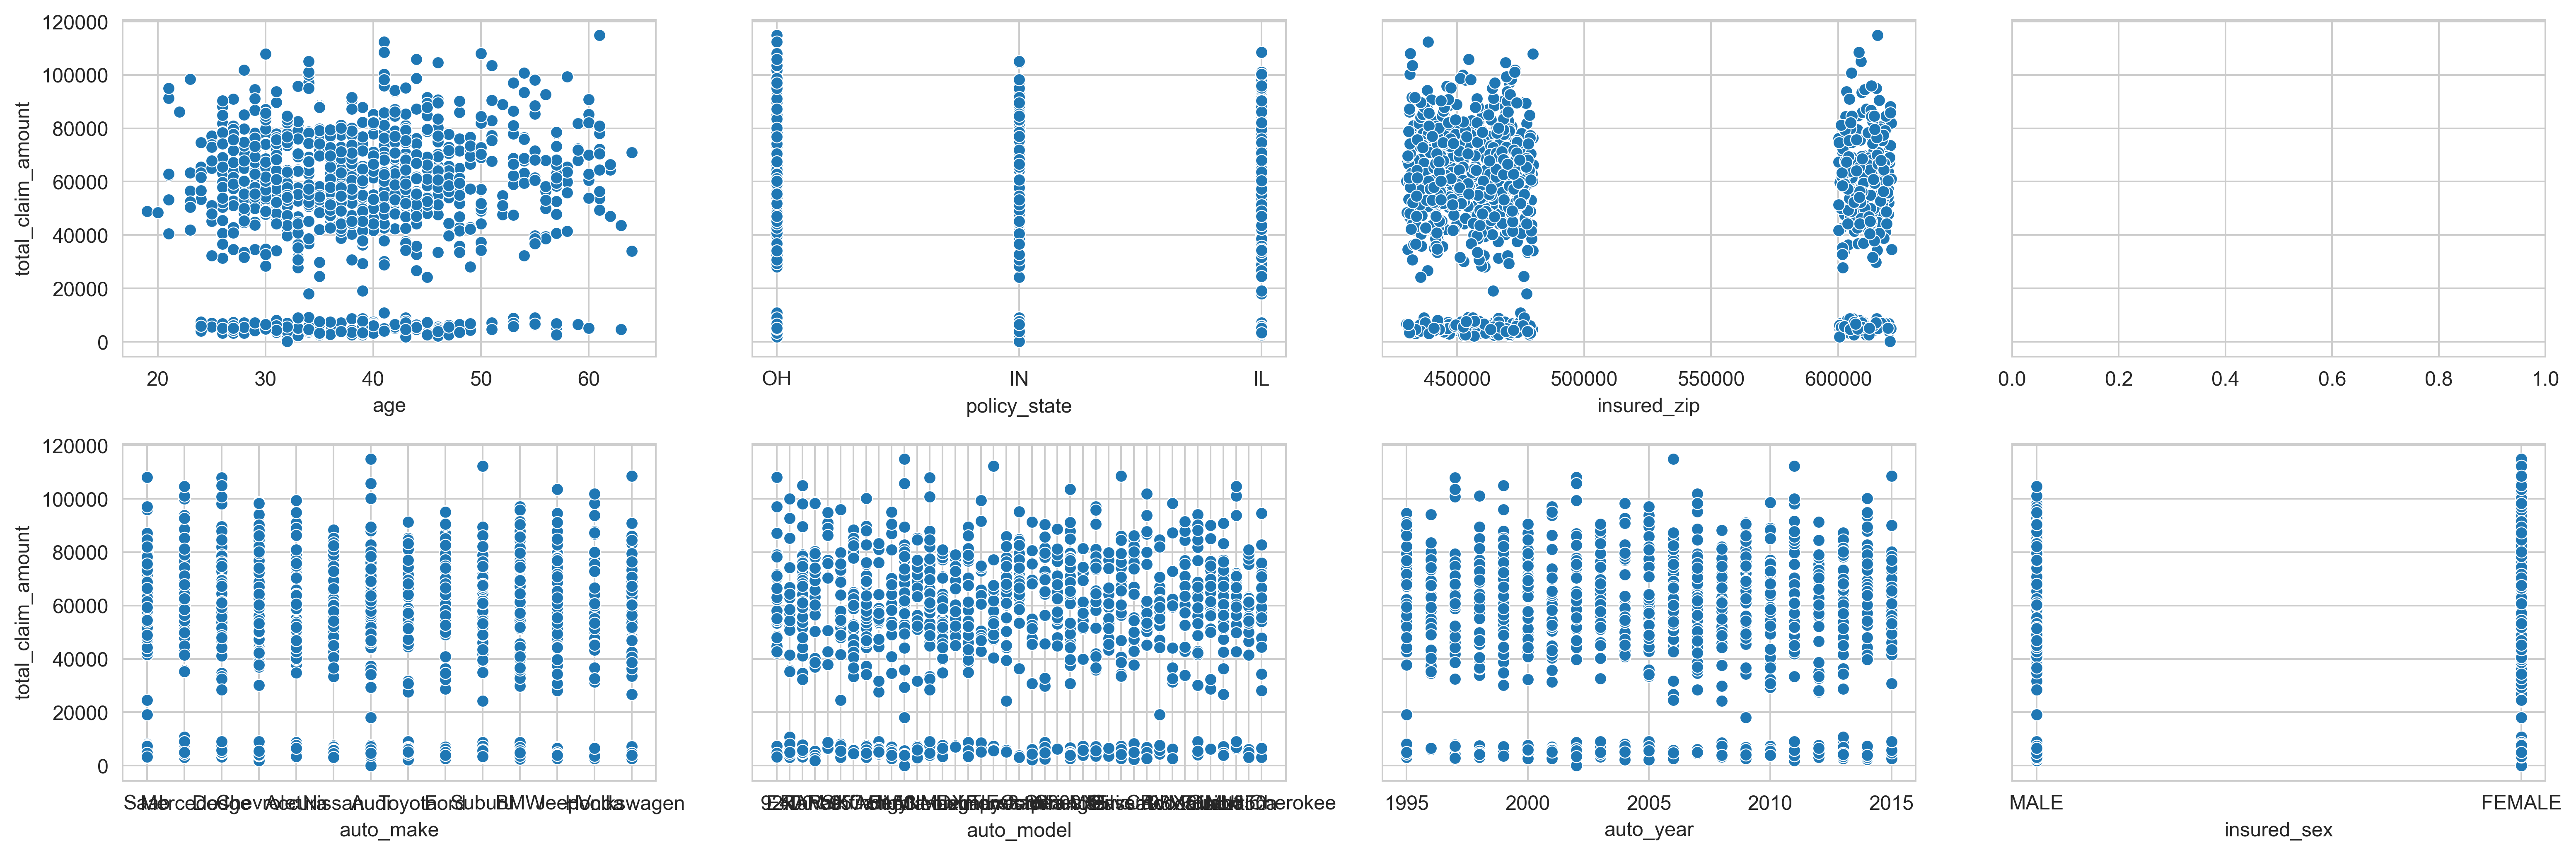

In [23]:
# Scatter plot visualisation des données

fig, axs = plt.subplots(ncols=4, nrows=2, sharey=True, figsize=(18, 6), dpi=350)

i = 1
for cat in ["age", "policy_state", "insured_zip", "insured_sex", "auto_make", "auto_model", "auto_year"]:
    sns.scatterplot(data=data[[cat, 'total_claim_amount']], ax=axs[int(i/4), (i-1)%4], x=cat, y="total_claim_amount")
    i += 1
plt.subplots_adjust(wspace=5.0)
plt.tight_layout()
plt.show()

In [ ]:
'''
1. On observe deux groupes de données dans le graphe en general :
      - un premier groupe assez concentré entre 0 - 20 000 (total_claim_amount)
      - un second groupe avec des valeur de total_claim_amount assez dispersé dans l'intervalle 20 000 - 120 000
2. Les villes (IN, IL) semble avoir des relations similaires avec total_claim_amount
   tandis que OH semble enregistrer des valeurs des sinistres avec des montants plus élévés
3. On observe deux clusters de données pour les codes postales (450000-50000) et (600000+)
   Ces deux profils ont des densités différentes.
4. Les femmes semblent avoir une assez grande diversité de sinistres et ont des sinistres plus couteux que les hommes

'''

In [26]:
# Split des données en données test/train

X_train, X_test, y_train, y_test = train_test_split(data[['age']].to_numpy(), mnt_sinistres, test_size = 0.25)

# Entrainement du modèle (v1)

ScoringModel(LinearRegression, 'Regression Linéaire (2)')

Regression Linéaire (2) Score :
 MAE: 20326.969472153898 
 RMSE : 26320.915100051247 
 R2 : 0.005086496635389071


In [ ]:
'''
    Les seules variables quelques peu significatives sont 'auto_model' et 'age'.
    Considérons pour le moment comme modèle de base meme si très insastifaisant.
    Voyons si les modèles de ML font mieux.
'''

"\nLes seules variables quelques peu significatives sont 'auto_model' et 'age'.\nConsidérons pour le moment comme modèle de base meme si très insastifaisant.\n"

In [34]:
# 4. Modèle de ML

X_train, X_test, y_train, y_test = train_test_split(data_encoded.to_numpy(), mnt_sinistres, test_size = 0.2)

# Random Forest

ScoringModel(RandomForestRegressor, 'Random Forest Regression', params={ 'n_estimators' : 1500, 'max_depth' : 15})


Random Forest Regression Score :
 MAE: 21865.92615611582 
 RMSE : 28010.145284800477 
 R2 : -0.15291510504953942


In [116]:
# Définir les paramètres à tester
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialiser le modèle
rf = RandomForestRegressor(random_state=42)

# Recherche sur grille
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Meilleurs paramètres
print("Best parameters found: ", grid_search.best_params_)

# Réentraîner avec les meilleurs paramètres
best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


c:\Python312\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters found:  {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [39]:

ScoringModel(RandomForestRegressor, 'Optimized Random Forest', {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200})

Optimized Random Forest Score :
 MAE: 20695.545947969407 
 RMSE : 26831.641761910105 
 R2 : -0.057940151589509936


In [ ]:
# Gradient Boosting

ScoringModel(GradientBoostingRegressor, 'Gradient Boosting', params={'n_estimators' : 400})


Gradient Boosting Score :
 MAE: 24578.873567067953 
 RMSE : 30210.841911317068 
 R2 : -0.24785740730538075


In [43]:
# Neural Network

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = scaler.fit_transform(data_encoded)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, mnt_sinistres, test_size=0.2, random_state=42)

nn_model = MLPRegressor(
    hidden_layer_sizes=(100,),  # One hidden layer with 100 neurons
    activation='relu',          # 'relu' activation function
    solver='adam',              # 'adam' solver for weight optimization
    max_iter=500,               # Set the number of iterations (epochs)
    random_state=42             # Set the seed for reproducibility
)

nn_model.fit(X_train, y_train)
y_pred = nn_model.predict(X_test)

print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

47805.99959491698
2950101602.967483
-3.432894939107836


C:\Users\chris\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# 5. Changement de strategie

'''
L'on ne va plus chercher à faire une prédiction directe des couts d'un sinistre. On va passer par une étape intermédiaire, i.e determiner si oui ou non en fonction des données
d'un individu s'il a des sinistres élevés (> 20 000) ou non (<= 20 000).
On va donc faire de la classification puis ensuite faire une regression pour améliorer la précision.

'''

In [334]:
# 6. Ajout de la variable claim_level (1: low, 2: high)

claim_level = mnt_sinistres.copy()
claim_level.loc[mnt_sinistres > 20000] = 1
claim_level.loc[mnt_sinistres <= 20000] = 0


<Axes: xlabel='total_claim_amount', ylabel='Density'>

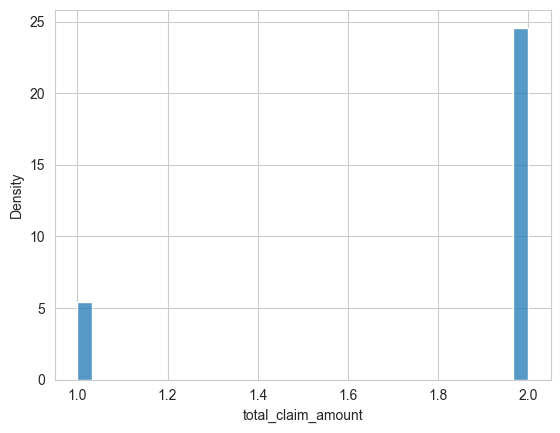

In [291]:
# Visualisation en densité de claim_level

sns.histplot(data=claim_level, kde=False, stat='density', bins=30)

In [292]:
'''
    Puisqu'on essaie de prédire une variable binaire, on peut se servir de la régression logistique.
    Faisons une comparaison des modèles pour la prédiction du claim_level
'''

"\n    Puisqu'on essaie de prédire une variable binaire, on peut se servir de la régression logistique.\n"

In [335]:
# 7. Prédiction de claim_level

X_train, X_test, y_train, y_test = train_test_split(data_encoded, claim_level, test_size=0.2, random_state=53)

# Régression logistique

from sklearn.linear_model import LogisticRegression

logistic_reg = LogisticRegression(max_iter = 300).fit(X_train, y_train)

y_pred = logistic_reg.predict(X_test)

print(mean_absolute_error(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))
print(logistic_reg.score(X_test,y_test))

0.2
0.2
0.8


In [336]:
'''
    Pour la classification, on utilise accurancy_score dans les métriques 
    mais pour la regression on utilise r2_score
    https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score
    https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html
'''

'\n    Pour la classification, on utilise accurancy_score dans les métriques \n    mais pour la regression on utilise r2_score\n    https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score\n    https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html\n'

In [337]:
# Random Forest

rfc = RandomForestClassifier()

rfc.fit(X_train, y_train)

print(rfc.score(X_test, y_test))

0.8


In [338]:
# AdaBoost

ada_boost = AdaBoostClassifier()

ada_boost.fit(X_train, y_train)

print(ada_boost.score(X_test, y_test))

0.79


C:\Users\chris\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [340]:
# XGBoost

xgb_model = xgb.XGBClassifier(objective='binary:logistic')

xgb_model.fit(X_train, y_train)

print(xgb_model.score(X_test, y_test))

0.72


In [341]:
# Gradient Boosting

gbc = GradientBoostingClassifier()

gbc.fit(X_train, y_train)

print(gbc.score(X_test, y_test))
# Le score change à chaque relance. Pourquoi ?

0.75


In [355]:
# Neural Network

from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = scaler.fit_transform(data_encoded)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, claim_level, test_size=0.2, random_state=42)

nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),  # One hidden layer with 100 neurons
    activation='relu',          # 'relu' activation function
    solver='adam',              # 'adam' solver for weight optimization
    max_iter=1400,               # Set the number of iterations (epochs)
    random_state=42             # Set the seed for reproducibility
)

nn_model.fit(X_train, y_train)
print(nn_model.score(X_test, y_test))

mean_absolute_error(y_pred, y_test)
mean_squared_error(y_pred, y_test)

0.73


np.float64(0.18)

In [ ]:
'''
    Pour le moment, je vais me contenter de la regression logistique sans chercher à optimiser les autres modèles, je le ferai plus tard
'''

In [ ]:
# 8. Prédiction de total_claim_amount sachant claim_level

'''
    On sait déja que l'on peut approximer
'''

In [44]:
# Split des données pour entrainer deux modèles sur les groupes de claim_level

data_claim_low = data_encoded[mnt_sinistres <= 20000][:]
mnt_sinistres_low = mnt_sinistres[mnt_sinistres <= 20000][:]

data_claim_high = data_encoded[mnt_sinistres > 20000][:]
mnt_sinistres_high = mnt_sinistres[mnt_sinistres > 20000][:]

In [ ]:
# Prédiction sur la partie high

X_train, X_test, y_train, y_test = train_test_split(data_claim_high.to_numpy(), mnt_sinistres_high, test_size=0.2, random_state = 123)

# Régression linéaire

ScoringModel(LinearRegression, identifier='Linear Regression High Claim')

Linear Regression High Claim Score :
 MAE: 1401.1946424935604 
 RMSE : 1842.489642270544 
 R2 : -0.408244317373583


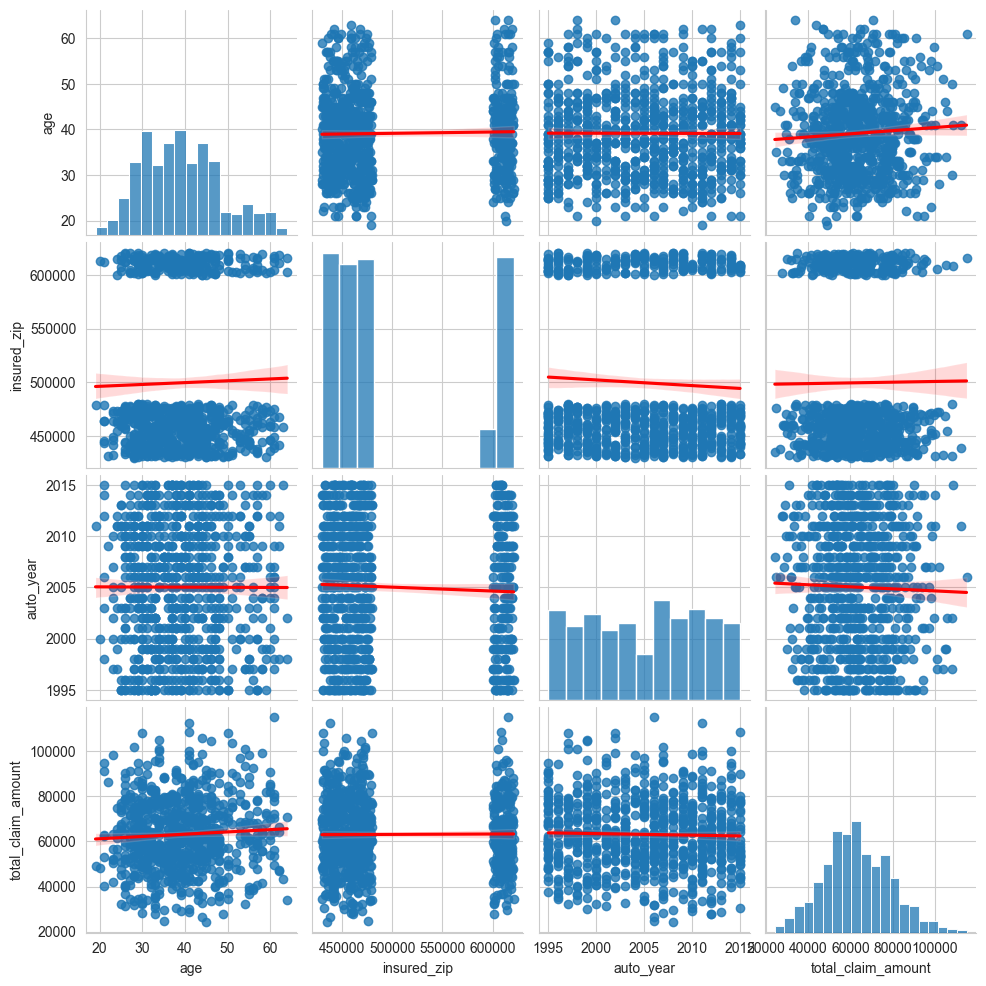

In [46]:
# Visualisation des données

sns.pairplot(data[mnt_sinistres > 20000][:], kind="reg", plot_kws={'line_kws':{'color':'red'}})

In [49]:
# Random Forest

ScoringModel(RandomForestRegressor, identifier='RandomForestRegressor')

RandomForestRegressor Score :
 MAE: 14353.381097560976 
 RMSE : 17345.67628572277 
 R2 : -0.1596957040781859


In [53]:
# Gradient Boosting

ScoringModel(GradientBoostingRegressor, identifier='GradienBoostingRegression')

GradienBoostingRegression Score :
 MAE: 1734.4119228263255 
 RMSE : 2492.82722583248 
 R2 : -1.5778180224823095


In [54]:
# Prédiction sur la partie low

X_train, X_test, y_train, y_test = train_test_split(data_claim_low.to_numpy(), mnt_sinistres_low, test_size=0.2, random_state = 123)

# Régression linéaire

ScoringModel(LinearRegression, identifier='Linear Regression High Claim')

Linear Regression High Claim Score :
 MAE: 1401.1946424935604 
 RMSE : 1842.489642270544 
 R2 : -0.408244317373583


In [55]:
# Random Forest

ScoringModel(RandomForestRegressor, identifier='RandomForestRegressor')

RandomForestRegressor Score :
 MAE: 1356.7722222222224 
 RMSE : 1769.7270098646416 
 R2 : -0.2992132935679028


In [56]:
# Gradient Boosting

ScoringModel(GradientBoostingRegressor, identifier='GradienBoostingRegression')

GradienBoostingRegression Score :
 MAE: 1787.2878556530368 
 RMSE : 2654.377650982492 
 R2 : -1.9227611188872884


In [115]:
# Gradient Boosting

ScoringModel(AdaBoostRegressor, identifier='GradienBoostingRegression')

GradienBoostingRegression Score :
 MAE: 1409.4735199446204 
 RMSE : 1697.4890522849953 
 R2 : -0.19531360123352592
